# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

#### The data represents multiple marketing campaings spanning approximately 5 years, between 2008 and 2013, conducted by a Portuguese banking institution, in order to examine and predict whether customers would subscribe to a term deposit.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd

In [3]:
bank_full = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [4]:
bank_full.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
bank_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

#### Reviewing the value counts for each cateogrical variable in order to explore the different categories, and in particular obtain an understanding of the prevalence of 'unknown' in each column, to help determine whether 'unknown' should be treated as missing values, or as a value of its own.

In [69]:
for col in bank_full.select_dtypes('object'):
    print(col)
    print(bank_full[col].value_counts())
    print()

job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
cel

#### Upon reviewing the dataset, there are no NaN values that need to be addressed. Our description is informing us that 'duration' should be discarded for an accurate predictive model. We will keep for benchmark purposes and likely discard for modeling.

#### There are several categorical variables with 'unknown' as the category, which is a category in and of itself. The one that is glaring is in the 'default' column, which has 32588 'no', 3 'yes', and 8597 'unknown'. 21% of the customers in the dataset are categorized as 'unkown', which might affect our modeling if we utilize this feature.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

### Business Objective
#### The objective is to analyze approximately 5 years worth of phone marketing campaign data from a Portuguese Banking Institution to determine whether customers are likely to subscribe to a Term Deposit. Our goal is to explore what features are most important in regards to determining whether a customer will subscribe to a term deposit, including customers' existing relationships with banks, broad economic factors, marketing campaign strategies, and customer demographics. We will utilize our results to identify the most influential drivers of customer behavior regarding subscriptions, provide analytics of ideal target customers, and make recommendations on future marketing campaigns, with the aim of maximizing efficacy and subscription rates.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

#### Keeping only features that would be related to or used for banking purposes. 

In [7]:
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
X = bank_full[bank_features]
y = bank_full['y']

In [8]:
print(X.shape)
print(y.shape)
print(X.head())

(41188, 7)
(41188,)
   age        job  marital    education  default housing loan
0   56  housemaid  married     basic.4y       no      no   no
1   57   services  married  high.school  unknown      no   no
2   37   services  married  high.school       no     yes   no
3   40     admin.  married     basic.6y       no      no   no
4   56   services  married  high.school       no      no  yes


In [9]:
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [10]:
# Creating transformer for object columns, OneHotEncoder for objects and StandardScaler for numeric (in this case, 'age').

transformer = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), make_column_selector(dtype_include=object)),
    (StandardScaler(), make_column_selector(dtype_include='number'))
)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)
    

In [13]:
# We can see that dataset is imbalanced, and y_train and y_test maintained proportions.

print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64
y
no     0.887344
yes    0.112656
Name: proportion, dtype: float64
y
no     0.887351
yes    0.112649
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [14]:
from sklearn.dummy import DummyClassifier

In [15]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
baseline_score = dummy.score(X_test, y_test)
print(baseline_score)

0.8873512988589464


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [17]:
log_r = Pipeline([
    ('transformer', transformer),
    ('model', LogisticRegression(random_state=42, max_iter=1000)),
])
log_r.fit(X_train, y_train)
    

,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Problem 9: Score the Model

What is the accuracy of your model?

In [18]:
log_r_score = log_r.score(X_test, y_test)
print(log_r_score)

0.8873512988589464


In [19]:
log_preds = log_r.predict(X_test)

pd.Series(log_preds).value_counts()

no    8238
Name: count, dtype: int64

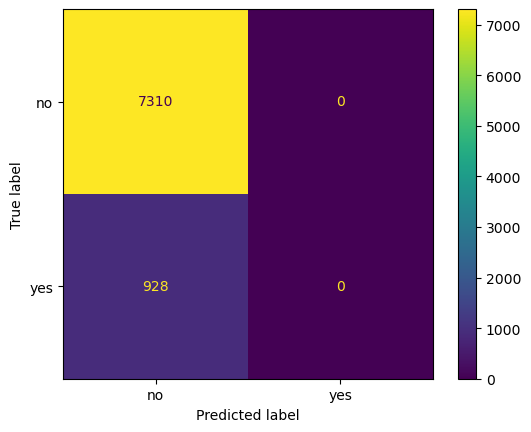

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(log_r, X_test, y_test)

In [21]:
from sklearn.metrics import classification_report

preds = log_r.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      7310
         yes       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Results of the Baseline and Logisitic Regression Models
#### The DummyClassifier model and the LogisticRegression model achieved identical scores of 88.7%. Our confusion matrix showcases that LogisticRegression predicted 100% of customers as not subscribing, as all predictions are 'no' values. The model did not predict any 'yes' values, and did not predict that any customers would subscribe, utlizing only bank related features. This tells us that accuracy score alone is not an adequate evaluation metric for this imbalanced classification problem, particualrly as we see that Recall for 'no' is 100%, while Recall for 'yes' is 0%.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [22]:
knn_pipe = Pipeline([
    ('transformer', transformer),
    ('model', KNeighborsClassifier())
])
knn_pipe.fit(X_train, y_train)

,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
knn_score = knn_pipe.score(X_test, y_test)
print(knn_score)

0.8784899247390143


In [24]:
dtree_pipe = Pipeline([
    ('transformer', transformer),
    ('model', DecisionTreeClassifier(random_state=42)),
     ])
dtree_pipe.fit(X_train, y_train)

,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
dtree_score = dtree_pipe.score(X_test, y_test)
print(dtree_score)

0.8650157805292547


In [26]:
svc_pipe = Pipeline([
    ('transformer', transformer),
    ('model', SVC())
])
svc_pipe.fit(X_train, y_train)

,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('standardscaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
svc_score = svc_pipe.score(X_test, y_test)
print(svc_score)

0.8863801893663511


In [28]:
import time

In [29]:
start = time.time()
log_r.fit(X_train, y_train)
log_r_time = time.time() - start

In [30]:
start = time.time()
knn_pipe.fit(X_train, y_train)
knn_pipe_time = time.time() - start

In [31]:
start = time.time()
dtree_pipe.fit(X_train, y_train)
dtree_time = time.time() - start

In [32]:
start = time.time()
svc_pipe.fit(X_train, y_train)
svc_pipe_time = time.time() - start

In [33]:
start = time.time()
dummy.fit(X_train, y_train)
dummy_time = time.time() - start

## Model Comparisons
### Based on Time and Accuracy

In [34]:
results = []

results.append({
    'Model' : 'Dummy Classifier',
    'Train Time (sec)' : dummy_time,
    'Train Accuracy' : dummy.score(X_train, y_train),
    'Test Accuracy' : dummy.score(X_test, y_test)
})

results.append({
    'Model' : 'Logistic Regression',
    'Train Time (sec)' : log_r_time,
    'Train Accuracy' : log_r.score(X_train, y_train),
    'Test Accuracy' : log_r.score(X_test, y_test)
})

results.append({
    'Model' : 'K Nearest Neighbors',
    'Train Time (sec)' : knn_pipe_time,
    'Train Accuracy' : knn_pipe.score(X_train, y_train),
    'Test Accuracy' : knn_pipe.score(X_test, y_test)
})

results.append({
    'Model' : 'Decision Tree',
    'Train Time (sec)' : dtree_time,
    'Train Accuracy' : dtree_pipe.score(X_train, y_train),
    'Test Accuracy' : dtree_pipe.score(X_test, y_test)
})

results.append({
    'Model' : 'Support Vector Machine',
    'Train Time (sec)' : svc_pipe_time,
    'Train Accuracy' : svc_pipe.score(X_train, y_train),
    'Test Accuracy' : svc_pipe.score(X_test, y_test)
})

results_df = pd.DataFrame(results)

results_df

,Model,Train Time (sec),Train Accuracy,Test Accuracy
0,Dummy Classifier,0.007185,0.887344,0.887351
1,Logistic Regression,0.053862,0.887344,0.887351
2,K Nearest Neighbors,0.037057,0.890258,0.878490
3,Decision Tree,0.200226,0.917056,0.865016
4,Support Vector Machine,25.015832,0.888164,0.886380


##### None of our models had a higher Test Accuracy than Logisitc Regression. We can see on the above table that SVM came close to Logisitc Regression, with Test Accuracy of .886, but the computational expense and the Train Time were relatively immense, taking 464 times longer than Logistic Regression. KNN was efficient, with faster Train Time, but a slightly lower Test Accuracy score of .878.

In [35]:
log_preds = log_r.predict(X_test)

knn_preds = knn_pipe.predict(X_test)

dtree_preds = dtree_pipe.predict(X_test)

svc_preds = svc_pipe.predict(X_test)

### Viewing Classification Reports to observe Precision, Recall, f1 scores, in addition to Accuracy.

### Logistic Regression Classification Report
#### 'yes' precision = 0, recall = 0, f1-score = 0

In [36]:
print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      7310
         yes       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### KNN Classification Report
#### 'yes' precision = 0.33, recall = 0.08, f1-score = 0.13

In [37]:
print(classification_report(y_test, knn_preds))

              precision    recall  f1-score   support

          no       0.89      0.98      0.93      7310
         yes       0.33      0.08      0.13       928

    accuracy                           0.88      8238
   macro avg       0.61      0.53      0.53      8238
weighted avg       0.83      0.88      0.84      8238



### Decision Tree Classification Report
#### 'yes' precision = 0.23, recall = 0.09, f1-score = 0.13

In [38]:
print(classification_report(y_test, dtree_preds))

              precision    recall  f1-score   support

          no       0.89      0.96      0.93      7310
         yes       0.23      0.09      0.13       928

    accuracy                           0.87      8238
   macro avg       0.56      0.53      0.53      8238
weighted avg       0.82      0.87      0.84      8238



### SVC Classification Report
#### 'yes' precision = 0.28, recall = 0.01, f1-score = 0.01

In [39]:
print(classification_report(y_test, svc_preds))

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      7310
         yes       0.28      0.01      0.01       928

    accuracy                           0.89      8238
   macro avg       0.58      0.50      0.48      8238
weighted avg       0.82      0.89      0.84      8238



### Classification Report Results
#### Recall, an important factor in terms of predicting customers that will subscribe ('yes') is highest with our Decision Tree model, although not good, at only .09. Recall for KNN is .08. Recall for Logistic Regression and SVC, however, are 0 and .01 respectively. This begins to showcase that our models struggled at capturing subscribers with such an imbalanced dataset, and utilizing our selected features. 

In [70]:
report_results = []

for model_name, preds in [
    ('Logistic Regression', log_preds),
    ('K Nearest Neighbors', knn_preds),
    ('Decision Tree', dtree_preds),
    ('Support Vector Machine', svc_preds)
]:
    report = classification_report(
        y_test,
        preds,
        output_dict=True,
        zero_division=0
    )
    
    report_results.append({
        'Model': model_name,
        'Precision (Yes)': report['yes']['precision'],
        'Recall (Yes)': report['yes']['recall'],
        'F1 (Yes)': report['yes']['f1-score']
    })

class_results_df = pd.DataFrame(report_results).round(3)

class_results_df

,Model,Precision (Yes),Recall (Yes),F1 (Yes)
0,Logistic Regression,0.000,0.000,0.000
1,K Nearest Neighbors,0.333,0.079,0.127
2,Decision Tree,0.233,0.086,0.126
3,Support Vector Machine,0.278,0.005,0.011


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

### Logistic Regression

In [40]:
from sklearn.model_selection import GridSearchCV

In [41]:
log_r_params = {
    'model__C': [.01, 0.1, 1.0, 10, 100]
}

log_r_grid = GridSearchCV(
    estimator=log_r,
    param_grid = log_r_params,
    cv = 5)

log_r_grid.fit(X_train, y_train)
print(log_r_grid.best_params_)
print(log_r_grid.best_score_)

{'model__C': 0.01}
0.8873444613050075


In [42]:
best_log_r = log_r_grid.best_estimator_
log_r_grid_preds = best_log_r.predict(X_test)
print(classification_report(y_test, log_r_grid_preds))

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      7310
         yes       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [71]:
lr_results = []

for C in [0.01, 0.1, 1, 10, 100]:

    lr = Pipeline([
        ('transformer', transformer),
        ('model', LogisticRegression(C=C, max_iter=1000))
    ])

    lr.fit(X_train, y_train)

    preds = lr.predict(X_test)

    report = classification_report(
        y_test,
        preds,
        output_dict=True,
        zero_division=0
    )

    lr_results.append({
        'C': C,
        'Accuracy': lr.score(X_test, y_test),
        'Recall (Yes)': report['yes']['recall']
    })

lr_results = pd.DataFrame(lr_results)

lr_results

,C,Accuracy,Recall (Yes)
0,0.01,0.887351,0.0
1,0.10,0.887351,0.0
2,1.00,0.887351,0.0
3,10.00,0.887351,0.0
4,100.00,0.887351,0.0


#### Changing our parameters using Logistic Regression did not produce any changes in our model's results. In fact, regardless of the C parameter, Accuracy and Recall were identical. This showcases our LR model's inability to predict subscribers with such an imbalanced dataset and the features we have selected. 

### K Nearest Neighbors

In [43]:
knn_params = {
    'model__n_neighbors': [1,3,5,7,11,15,21]
}

knn_grid = GridSearchCV(
    estimator = knn_pipe,
    param_grid = knn_params,
    cv = 5
)

knn_grid.fit(X_train, y_train)
print(knn_grid.best_params_)
print(knn_grid.best_score_)

{'model__n_neighbors': 21}
0.8864946889226101


In [44]:
best_knn = knn_grid.best_estimator_

knn_grid_preds = best_knn.predict(X_test)

print(classification_report(y_test, knn_grid_preds))

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      7310
         yes       0.48      0.03      0.06       928

    accuracy                           0.89      8238
   macro avg       0.69      0.51      0.50      8238
weighted avg       0.84      0.89      0.84      8238



In [45]:
knn_results = []

for k in [1, 3, 5, 7, 9, 11, 15, 21]:
    
    knn = Pipeline([
        ('transformer', transformer),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])

    knn.fit(X_train, y_train)

    preds = knn.predict(X_test)

    report = classification_report(y_test, preds, output_dict=True)

    knn_results.append({
    'k': k,
    'Accuracy': knn.score(X_test, y_test),
    'Recall (yes)': report['yes']['recall']
})

    print(f"k = {k}")
    print(f"Accuracy: {knn.score(X_test, y_test):.3f}")
    print(f"Recall (yes): {report['yes']['recall']:.3f}")
    print()

knn_results = pd.DataFrame(knn_results)

knn_results

k = 1
Accuracy: 0.813
Recall (yes): 0.172

k = 3
Accuracy: 0.867
Recall (yes): 0.086

k = 5
Accuracy: 0.878
Recall (yes): 0.079

k = 7
Accuracy: 0.884
Recall (yes): 0.065

k = 9
Accuracy: 0.885
Recall (yes): 0.046

k = 11
Accuracy: 0.886
Recall (yes): 0.042

k = 15
Accuracy: 0.887
Recall (yes): 0.038

k = 21
Accuracy: 0.887
Recall (yes): 0.032



,k,Accuracy,Recall (yes)
0,1,0.812576,0.172414
1,3,0.867322,0.086207
2,5,0.878490,0.078664
3,7,0.883952,0.064655
4,9,0.884681,0.046336
5,11,0.885895,0.042026
6,15,0.887109,0.037716
7,21,0.887109,0.032328


#### KNN's best parameters in terms of Accuracy based on this test was k=21. We can see that Accuracy increased as k increased, and began to level between k=15 and k=21. Recall, however, was highest with the lowest k (k=1) and continued to decrease as k increased. If we choose KNN as our model, this is a valuable tradeoff, if our goal is to capture as many subscribing customers as possible.

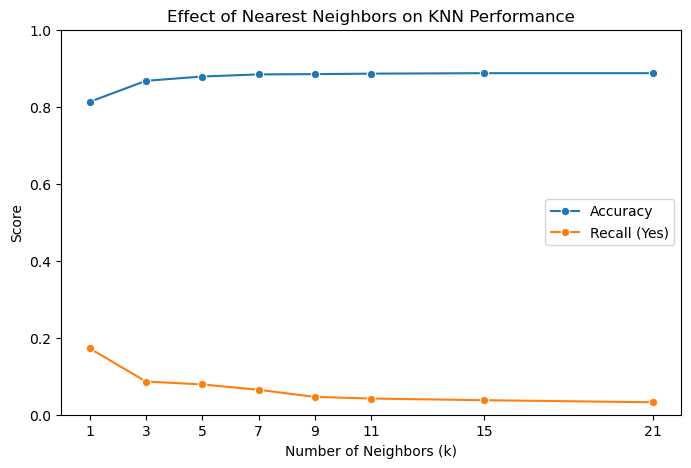

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.lineplot(data=knn_results,
             x='k',
             y='Accuracy',
             marker='o',
             label='Accuracy')

sns.lineplot(data=knn_results,
             x='k',
             y='Recall (yes)',
             marker='o',
             label='Recall (Yes)')

plt.title('Effect of Nearest Neighbors on KNN Performance')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Score')
plt.xticks(knn_results['k'])
plt.ylim(0, 1)

plt.show()

### Decision Tree

In [47]:
dtree_params = {
    'model__max_depth': [3,5,7,10,None],
    'model__min_samples_split': [2,5,10],
    'model__min_samples_leaf': [1,2,5]
}

dtree_grid = GridSearchCV(
    estimator = dtree_pipe,
    param_grid = dtree_params,
    cv = 5
)

dtree_grid.fit(X_train, y_train)

print(dtree_grid.best_params_)
print(dtree_grid.best_score_)

{'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2}
0.8873444613050075


In [48]:
best_tree = dtree_grid.best_estimator_

tree_grid_preds = best_tree.predict(X_test)

print(classification_report(y_test, tree_grid_preds))

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      7310
         yes       0.51      0.03      0.05       928

    accuracy                           0.89      8238
   macro avg       0.70      0.51      0.49      8238
weighted avg       0.85      0.89      0.84      8238



In [49]:
depth_results = []

for depth in [3, 5, 7, 10, None]:

    tree = Pipeline([
        ('transformer', transformer),
        ('model', DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    tree.fit(X_train, y_train)

    preds = tree.predict(X_test)

    report = classification_report(y_test, preds, output_dict=True)

    depth_results.append({
        'Max Depth': depth,
        'Accuracy': tree.score(X_test, y_test),
        'Recall (yes)': report['yes']['recall']
    })

depth_results = pd.DataFrame(depth_results)

depth_results

,Max Depth,Accuracy,Recall (yes)
0,3.0,0.887351,0.025862
1,5.0,0.887230,0.030172
2,7.0,0.886380,0.020474
3,10.0,0.883952,0.028017
4,NaN,0.865016,0.086207


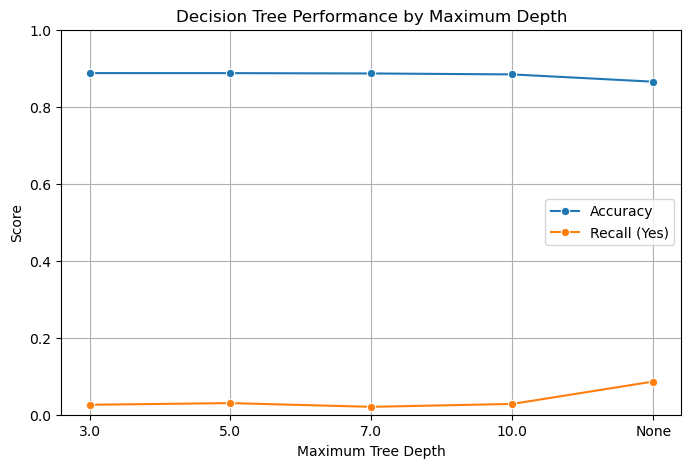

In [50]:
depth_results['Max Depth'] = depth_results['Max Depth'].astype(str)
depth_results.loc[depth_results['Max Depth'] == 'nan', 'Max Depth'] = 'None'

plt.figure(figsize=(8,5))

sns.lineplot(
    data=depth_results,
    x='Max Depth',
    y='Accuracy',
    marker='o',
    label='Accuracy'
)

sns.lineplot(
    data=depth_results,
    x='Max Depth',
    y='Recall (yes)',
    marker='o',
    label='Recall (Yes)'
)

plt.title('Decision Tree Performance by Maximum Depth')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Score')
plt.ylim(0,1)
plt.grid(True)

plt.show()

#### Recall, althgouh low at just under 9% at its max with Decision Tree, increases with no max depth restrictions. Accuracy, however, is highest with the lowest max depth at 3 in our example. 

### SVC Tuning
#### Attempted to tune hyperparamters for SVC utilizing GridSearch, as well as setting manual parameters, and I have concluded that it is too computationally expensive and time consuming. I interrupted after nearly 30 mins of running.

In [51]:
svc_params = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear']
}

In [ ]:
svc_grid = GridSearchCV(
    estimator= svc_pipe,
    param_grid= svc_params,
    cv=5
)

svc_grid.fit(X_train, y_train)

print(svc_grid.best_params_)
print(svc_grid.best_score_)

#### Canceled SVC GridSearch attempt due to computational expense and time

In [ ]:
from sklearn.metrics import classification_report

svc_results = []

for c in [0.01, 0.1, 1, 10]:

    svc = Pipeline([
        ('transformer', transformer),
        ('model', SVC(
            C=c,
            kernel='linear'
        ))
    ])

    svc.fit(X_train, y_train)

    preds = svc.predict(X_test)

    report = classification_report(
        y_test,
        preds,
        output_dict=True
    )

    svc_results.append({
        'C': c,
        'Accuracy': svc.score(X_test, y_test),
        'Recall (yes)': report['yes']['recall'],
        'Precision (yes)': report['yes']['precision'],
        'F1 (yes)': report['yes']['f1-score']
    })

svc_results = pd.DataFrame(svc_results)

svc_results

#### Canceled manual SVC attempt due to computational expense and time

### Tuned Model Results

In [57]:
tuned_report_results = []

for model_name, preds in [
    ('Tuned Logistic Regression', log_r_grid_preds),
    ('Tuned KNN', knn_grid_preds),
    ('Tuned Decision Tree', tree_grid_preds)
]:
    report = classification_report(
        y_test,
        preds,
        output_dict=True,
        zero_division=0
    )
    
    tuned_report_results.append({
        'Model': model_name,
        'Precision (Yes)': report['yes']['precision'],
        'Recall (Yes)': report['yes']['recall'],
        'F1 (Yes)': report['yes']['f1-score']
    })

tuned_class_results_df = pd.DataFrame(tuned_report_results).round(3)

tuned_class_results_df

,Model,Precision (Yes),Recall (Yes),F1 (Yes)
0,Tuned Logistic Regression,0.000,0.000,0.000
1,Tuned KNN,0.484,0.032,0.061
2,Tuned Decision Tree,0.511,0.026,0.049


In [58]:
display(results_df)

display(class_results_df)

display(tuned_class_results_df)

,Model,Train Time (sec),Train Accuracy,Test Accuracy
0,Dummy Classifier,0.007185,0.887344,0.887351
1,Logistic Regression,0.053862,0.887344,0.887351
2,K Nearest Neighbors,0.037057,0.890258,0.878490
3,Decision Tree,0.200226,0.917056,0.865016
4,Support Vector Machine,25.015832,0.888164,0.886380


,Model,Precision (Yes),Recall (Yes),F1 (Yes)
0,Logistic Regression,0.000,0.000,0.000
1,K Nearest Neighbors,0.333,0.079,0.127
2,Decision Tree,0.233,0.086,0.126
3,Support Vector Machine,0.278,0.005,0.011


,Model,Precision (Yes),Recall (Yes),F1 (Yes)
0,Tuned Logistic Regression,0.000,0.000,0.000
1,Tuned KNN,0.484,0.032,0.061
2,Tuned Decision Tree,0.511,0.026,0.049


## Coefficients

#### Showing positive and negative coefficients from our Logistic Regression model to explore insights regarding which features and characteristics are associated with a higher or lower liklihood of customer subscription to a term deposit.

In [73]:
feature_names = log_r.named_steps['transformer'].get_feature_names_out()
coefs = log_r.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
})

coef_df['Feature'] = coef_df['Feature'].str.replace(
    'onehotencoder__',
    '',
    regex=False
)

coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()

positive_coef = coef_df.sort_values(
    'Coefficient',
    ascending=False
)

negative_coef = coef_df.sort_values(
    'Coefficient'
)

positive_coef.head(10)


,Feature,Coefficient,Absolute Coefficient
8,job_student,0.973354,0.973354
5,job_retired,0.629766,0.629766
10,job_unemployed,0.161930,0.161930
33,standardscaler__age,0.141469,0.141469
23,education_unknown,0.090942,0.090942
24,default_no,0.053921,0.053921
20,education_illiterate,0.030403,0.030403
15,marital_unknown,0.022100,0.022100
22,education_university.degree,0.016957,0.016957
26,default_yes,-0.009046,0.009046


In [63]:
negative_coef.head(10)

,Feature,Coefficient,Absolute Coefficient
25,default_unknown,-0.878295,0.878295
12,marital_divorced,-0.491329,0.491329
1,job_blue-collar,-0.485708,0.485708
2,job_entrepreneur,-0.464586,0.464586
7,job_services,-0.448804,0.448804
18,education_basic.9y,-0.343685,0.343685
13,marital_married,-0.335149,0.335149
27,housing_no,-0.305382,0.305382
32,loan_yes,-0.296367,0.296367
9,job_technician,-0.279790,0.279790


<Axes: xlabel='Coefficient', ylabel='Feature'>

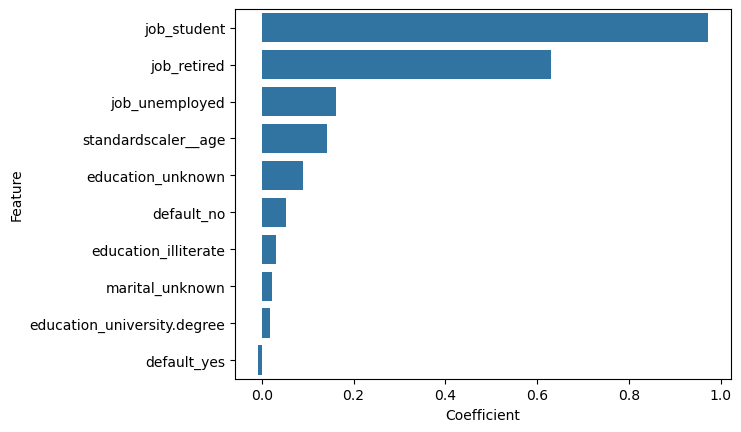

In [65]:
top_positive = positive_coef.head(10)

sns.barplot(
    data=top_positive,
    x='Coefficient',
    y='Feature'
)

<Axes: xlabel='Coefficient', ylabel='Feature'>

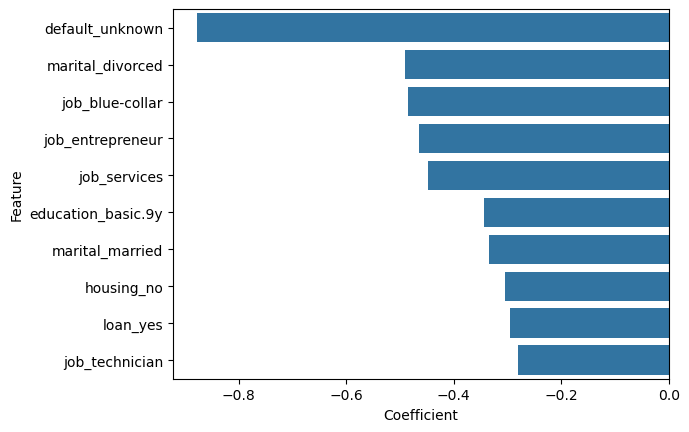

In [66]:
top_negative = negative_coef.head(10)

sns.barplot(
    data=top_negative,
    x='Coefficient',
    y='Feature'
)

## Summary and Recommendations

### What our models tell us.
#### Based on our primary objective of analyzing approximately 5 years worth of phone marketing campaign data from a Portuguese Banking Institution in order to determine whether customers are likely to subscribe to a Term Deposit, we have found that utilizing bank-related features from this dataset, our models were able to achieve high accuracy, in the range of 89%, but our models were not effective at identifying customers who subscribed, as indicated by low Recall. This is due to the fact that only about 11% of customers in our dataset subscribed ('yes'), versus 89% that did not subscribe. Our models struggled to identify customers that subscribed, based on the selected features and the imbalanced data.

### Business Recommendations
#### In order to obtain potentially more accurate predictions and higher recall, bank-only features should not be solely relied upon. We should attempt to incorporate other features from our dataset, including data points from previous marketing campaigns, and broader economic factors.

#### What we can glean from our findings are features that are associated to a higher or lower liklihood of subscription.

#### Features associated with a higher liklihood of subscription include job status of 'student', 'retired', and 'unemployed'. Next is age, then an 'unknown' status of education.

#### The top feature associated with lower liklihood of subscription is default status of 'unknown'. This is interesting, since the unknown status does not inform us whether the customer has defaulted or not, but the weight of this variable is significant in terms of not subscribing. This poses several questions: Why is default status unknown? Is it a data error? Did the customer not provide factual information? Does unknown here indicate a higher rate of actual default, which might enlighten us as to the customer's financial standing, possibly informing us that they do not have funds for term deposit? Or is this completely arbitrary and unrelated?

#### The following features associated with a liklihood of not subscribing include 'divorced', 'blue collar job', 'entrepreneur', 'services job', 'education basic 9y', 'married', 'no housing', 'loan status yes', 'technician job'.

#### In addition to further exploration while including exempted features (marketing campaign status and economic factors), more research would be valuable regarding effectiveness of demographics to target with marketing, particularly students and retired professionals. What would make a student more likely to subscribe? Are they inclined to deposit student loan money? Are they more likely to take financial risks? As for retired professionals, perhaps they've already acquired their nest egg and are more willing to subscribe to a term deposit with a goal of diversifying.

##### Questions